In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from datetime import datetime

In [2]:
cars = pd.read_csv(r"..\datasets\drom_archive_2017-2025_clean.csv")

In [4]:
cars = cars.drop(columns=['color'])

In [20]:
cars.info(show_counts=True)

<class 'pandas.DataFrame'>
RangeIndex: 8344773 entries, 0 to 8344772
Data columns (total 19 columns):
 #   Column          Non-Null Count    Dtype         
---  ------          --------------    -----         
 0   car_name        8344773 non-null  str           
 1   year            8344773 non-null  float64       
 2   date_posted     8344773 non-null  datetime64[us]
 3   price           8344773 non-null  float64       
 4   engine_volume   8344292 non-null  float64       
 5   engine_type     8344540 non-null  str           
 6   power           8343972 non-null  float64       
 7   transmission    8344359 non-null  str           
 8   drive           8344402 non-null  str           
 9   mileage         7915160 non-null  float64       
 10  steering_wheel  8336332 non-null  str           
 11  generation      8341673 non-null  float64       
 12  restyling       8341673 non-null  float64       
 13  body_type       8323139 non-null  str           
 14  city            8344773 non-n

In [19]:
cars['date_posted'] = pd.to_datetime(cars['date_posted'])

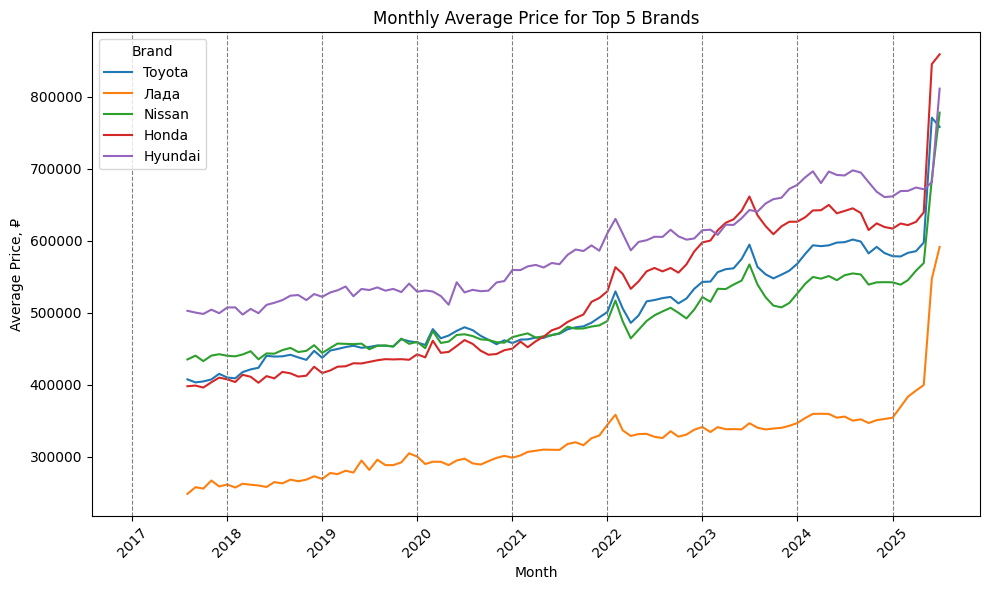

In [24]:
# 1. Identify Top 5 brands by total listings count
top_brands = cars['marka'].value_counts().head(5).index.tolist()

# 2. Calculate monthly average price for these brands
monthly_avg_by_brand = (
    cars[cars['marka'].isin(top_brands)]
    .groupby([cars['date_posted'].dt.to_period('M'), 'marka'])['price']
    .mean()
    .unstack('marka')
)
monthly_avg_by_brand.index = monthly_avg_by_brand.index.to_timestamp()

# 3. Plot time series for each brand
plt.figure(figsize=(10, 6))
for brand in top_brands:
    plt.plot(monthly_avg_by_brand.index, monthly_avg_by_brand[brand], label=brand)

# 4. Add vertical lines at each January 1st for year boundaries
start_year = monthly_avg_by_brand.index.year.min()
end_year   = monthly_avg_by_brand.index.year.max()
for year in range(start_year, end_year + 1):
    plt.axvline(pd.Timestamp(year=year, month=1, day=1),
                linestyle='--', color='grey', linewidth=0.8)

# 5. Finalize plot
plt.title('Monthly Average Price for Top 5 Brands')
plt.xlabel('Month')
plt.ylabel('Average Price, ₽')
plt.legend(title='Brand')
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

In [25]:
monthly_avg_by_brand = (
    cars[cars['marka'].isin(top_brands)]
    .groupby([cars['date_posted'].dt.to_period('M'), 'marka'])['price']
    .mean()
    .unstack('marka')
)

monthly_avg_by_brand

marka,Honda,Hyundai,Nissan,Toyota,Лада
date_posted,,,,,
2017-08,397894.688009,502603.331096,435054.301645,407434.100295,248404.192913
2017-09,398822.988731,500151.356944,440331.772752,403220.125777,257773.450968
2017-10,396040.130585,498246.813849,432785.464420,404548.765055,255762.047160
2017-11,403393.263589,504220.313662,440408.233538,407319.337667,266960.581138
2017-12,409855.578873,499297.520875,442335.384702,415111.680681,258835.703549
...,...,...,...,...,...
2025-03,621554.673301,669054.428503,545120.569260,583070.756803,383231.396052
2025-04,626008.363544,673749.739732,558248.536910,585344.991728,391899.645463
2025-05,639226.428271,671401.067728,568902.959674,597309.106806,399539.600164
